# **Descripcion del Dataset**
Riesgo de Crédito - Dataset

Descripción:

Este conjunto de datos reúne información sobre solicitudes de préstamos bancarios, considerando características financieras, laborales, personales y crediticias de los solicitantes. Su propósito es analizar patrones asociados al riesgo crediticio y estudiar qué factores pueden influir en el incumplimiento o no pago de un préstamo.

Fuente: Kaggle: https://www.kaggle.com/datasets/daniellopez01/credit-risk/data

Cada fila representa a una persona que solicita un préstamo e incluye información relacionada con su situación económica, historial crediticio, condiciones del préstamo y características personales relevantes para evaluar su nivel de riesgo.

El conjunto de datos contiene 1.000 filas (solicitudes de préstamo) y 17 columnas (variables).



### **Importación de Librerías**

In [1]:
# Importamos pandas para el manejo de tablas (DataFrames)
import pandas as pd

# Importamos numpy para operaciones matemáticas y manejo de valores nulos
import numpy as np

# Importamos matplotlib y seaborn para las visualizaciones y gráficos
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

### **Carga del Conjunto de Datos**

In [2]:
# Cargamos el dataset indicando el nombre exacto del archivo
df = pd.read_csv('C:/Users/yuril/OneDrive/Escritorio/Proyectos skillnest cientifico de datos/Proyecto 2 – Parte I (Core)/dataset/credit.csv')

# Primeros 5 registros del conjunto de datos
df.head()

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,< 0 DM,6,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,yes,no
1,1 - 200 DM,48,good,furniture/appliances,5951,< 100 DM,1 - 4 years,2,2,22,none,own,1,skilled,1,no,yes
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 years,2,3,49,none,own,1,unskilled,2,no,no
3,< 0 DM,42,good,furniture/appliances,7882,< 100 DM,4 - 7 years,2,4,45,none,other,1,skilled,2,no,no
4,< 0 DM,24,poor,car,4870,< 100 DM,1 - 4 years,3,4,53,none,other,2,skilled,2,no,yes


### **Dimensiones del Dataset**

In [3]:
# df.shape devuelve una tupla: (filas, columnas)
df.shape

(1000, 17)

In [ ]:
filas, columnas = df.shape

print("Cantidad de filas:", filas)
print("Cantidad de columnas:", columnas)

#El dataset contiene 1000 registros y 17 variables. Cada fila representa a un cliente o solicitud de crédito, mientras que las columnas describen características financieras, personales y la variable objetivo relacionada con el incumplimiento de pago.

Cantidad de filas: 1000
Cantidad de columnas: 17


### **Tipos de Datos y Estructura Básica**

In [6]:
# Muestra un resumen del tipo de datos por columna y la memoria utilizada
df.info()

#Se observa que el dataset contiene variables numéricas y categóricas. Las variables numéricas incluyen información como duración del préstamo, monto solicitado, edad y cantidad de préstamos existentes. Las variables categóricas representan características como historial crediticio, balance de cuenta, propósito del crédito, empleo, vivienda y la variable objetivo `default`.

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   checking_balance      1000 non-null   str  
 1   months_loan_duration  1000 non-null   int64
 2   credit_history        1000 non-null   str  
 3   purpose               1000 non-null   str  
 4   amount                1000 non-null   int64
 5   savings_balance       1000 non-null   str  
 6   employment_duration   1000 non-null   str  
 7   percent_of_income     1000 non-null   int64
 8   years_at_residence    1000 non-null   int64
 9   age                   1000 non-null   int64
 10  other_credit          1000 non-null   str  
 11  housing               1000 non-null   str  
 12  existing_loans_count  1000 non-null   int64
 13  job                   1000 non-null   str  
 14  dependents            1000 non-null   int64
 15  phone                 1000 non-null   str  
 16  default           

#### **Revision nombres de columnas**

In [7]:
df.columns
#Se revisan los nombres de las columnas para identificar las variables disponibles en el dataset.


Index(['checking_balance', 'months_loan_duration', 'credit_history', 'purpose',
       'amount', 'savings_balance', 'employment_duration', 'percent_of_income',
       'years_at_residence', 'age', 'other_credit', 'housing',
       'existing_loans_count', 'job', 'dependents', 'phone', 'default'],
      dtype='str')

#### **Separacion de variables numéricas y categóricas**

In [8]:
columnas_numericas = df.select_dtypes(include=np.number).columns
columnas_categoricas = df.select_dtypes(include="object").columns

print("Variables numéricas:")
print(columnas_numericas)

print("Variables categóricas:")
print(columnas_categoricas)

Variables numéricas:
Index(['months_loan_duration', 'amount', 'percent_of_income',
       'years_at_residence', 'age', 'existing_loans_count', 'dependents'],
      dtype='str')
Variables categóricas:
Index(['checking_balance', 'credit_history', 'purpose', 'savings_balance',
       'employment_duration', 'other_credit', 'housing', 'job', 'phone',
       'default'],
      dtype='str')


Se separan las variables numéricas y categóricas para facilitar el análisis. 
Las variables numéricas serán utilizadas para estadísticas descriptivas, histogramas, boxplots y correlaciones. 
Las variables categóricas serán revisadas mediante conteos de frecuencia y gráficos de barras.

### **Análisis Estadístico Descriptivo**

### **Variables Numéricas**

In [10]:
# Estadísticas descriptivas para variables numéricas
df.describe().T
#El análisis descriptivo permite observar medidas como media, desviación estándar, mínimo, máximo y cuartiles. En este dataset se puede observar, por ejemplo, que la duración promedio de los préstamos es cercana a 21 meses y que el monto promedio solicitado es aproximadamente 3271. También se aprecia que existen créditos con montos bastante superiores al promedio, lo que podría indicar la presencia de outliers.

,count,mean,std,min,25%,50%,75%,max
months_loan_duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
percent_of_income,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
years_at_residence,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
existing_loans_count,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
dependents,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0


### **Variables Categóricas**

In [ ]:
# Distribución de variables categóricas
df.describe(include='object').T

,count,unique,top,freq
Employee_ID,3000,3000,AIJ-100000,1
Job_Title,3000,20,Software Developer,164
Industry,3000,10,Energy,335
Country,3000,10,UAE,347
Education_Level,3000,4,Bachelor,782
Remote_Work_Possibility,3000,3,Hybrid,1011
Required_Skills,3000,2937,"Cloud Computing, Kubernetes, Leadership",3
Automation_Level,3000,3,Low,1037
Company_Size,3000,3,Medium,1025
AI_Tool_Usage,3000,3,Low,1033


Las variables categóricas permiten conocer la distribución de los grupos dentro del dataset. 
Por ejemplo, se puede revisar qué categoría aparece con mayor frecuencia en variables como historial crediticio, tipo de vivienda, empleo, propósito del préstamo y default.

#### **Revision valores variable categóricas**

In [11]:
# Revisamos los valores únicos y sus frecuencias
for col in columnas_categoricas:
    print("\nColumna:", col)
    print("Cantidad de valores únicos:", df[col].nunique())
    print(df[col].value_counts())


Columna: checking_balance
Cantidad de valores únicos: 4
checking_balance
unknown       394
< 0 DM        274
1 - 200 DM    269
> 200 DM       63
Name: count, dtype: int64

Columna: credit_history
Cantidad de valores únicos: 5
credit_history
good         530
critical     293
poor          88
very good     49
perfect       40
Name: count, dtype: int64

Columna: purpose
Cantidad de valores únicos: 6
purpose
furniture/appliances    473
car                     337
business                 97
education                59
renovations              22
car0                     12
Name: count, dtype: int64

Columna: savings_balance
Cantidad de valores únicos: 5
savings_balance
< 100 DM         603
unknown          183
100 - 500 DM     103
500 - 1000 DM     63
> 1000 DM         48
Name: count, dtype: int64

Columna: employment_duration
Cantidad de valores únicos: 5
employment_duration
1 - 4 years    339
> 7 years      253
4 - 7 years    174
< 1 year       172
unemployed      62
Name: count, dtype:

En la variable `purpose` aparece una categoría llamada `car0`, que probablemente representa una incongruencia o error de escritura de la categoría `car`. 
Esto debería ser corregido antes de entrenar un modelo predictivo.

También aparecen categorías como `unknown` en variables como `checking_balance` y `savings_balance`. En este caso no necesariamente representan valores nulos, sino una categoría informativa que indica que el dato no es conocido o no está disponible.

### **Detección y Corrección de Incongruencias Categóricas**
Se realizó una auditoría de las principales variables categóricas del dataset con el objetivo de identificar posibles inconsistencias en los valores.

Este proceso permite revisar si existen categorías repetidas con diferencias de escritura, uso de mayúsculas o minúsculas, espacios adicionales o valores mal registrados.

Esta revisión es importante porque las variables categóricas deben estar correctamente estandarizadas antes de realizar análisis más profundos o aplicar modelos de machine learning.

In [12]:
# Le decimos a pandas que no recorte el contenido de las columnas
pd.set_option("display.max_colwidth", None)

# Definimos las columnas categóricas que queremos analizar
columnas_objetivo = [
    "checking_balance",
    "credit_history",
    "purpose",
    "savings_balance",
    "employment_duration",
    "other_credit",
    "housing",
    "job",
    "phone",
    "default"
]

# Creamos una lista para guardar el diagnóstico
lista_resumen = []

for col in columnas_objetivo:
    if col in df.columns:
        cantidad_unicos = df[col].nunique(dropna=False)
        todos_los_valores = df[col].dropna().unique().tolist()
        
        lista_resumen.append({
            "Columna": col,
            "Cantidad de valores únicos": cantidad_unicos,
            "Valores encontrados": todos_los_valores
        })

# Convertimos la lista en DataFrame
resumen_categoricas = pd.DataFrame(lista_resumen)

resumen_categoricas

,Columna,Cantidad de valores únicos,Valores encontrados
0,checking_balance,4,"[< 0 DM, 1 - 200 DM, unknown, > 200 DM]"
1,credit_history,5,"[critical, good, poor, perfect, very good]"
2,purpose,6,"[furniture/appliances, education, car, business, renovations, car0]"
3,savings_balance,5,"[unknown, < 100 DM, 500 - 1000 DM, > 1000 DM, 100 - 500 DM]"
4,employment_duration,5,"[> 7 years, 1 - 4 years, 4 - 7 years, unemployed, < 1 year]"
5,other_credit,3,"[none, bank, store]"
6,housing,3,"[own, other, rent]"
7,job,4,"[skilled, unskilled, management, unemployed]"
8,phone,2,"[yes, no]"
9,default,2,"[no, yes]"


In [13]:
# Corregimos la categoría car0, ya que parece ser un error de escritura de car
df["purpose"] = df["purpose"].replace("car0", "car")

# Verificamos nuevamente los valores de purpose
df["purpose"].value_counts()

purpose
furniture/appliances    473
car                     349
business                 97
education                59
renovations              22
Name: count, dtype: int64

Se detectó una posible incongruencia en la variable `purpose`, donde aparece la categoría `car0`. 
Como esta categoría parece representar un error de escritura de `car`, se reemplaza por la categoría correcta. 
Esta limpieza permite evitar que el modelo interprete `car0` como una categoría distinta.

### **Identificación de Valores Nulos, Duplicados y Outliers**

#### **Detección de Valores Nulos**

In [14]:
# Revisamos la cantidad de valores nulos por columna
nulos = df.isnull().sum()

# Calculamos el porcentaje de valores nulos
porcentaje_nulos = df.isnull().mean() * 100

# Creamos una tabla resumen
tabla_nulos = pd.DataFrame({
    "Valores nulos": nulos,
    "Porcentaje (%)": porcentaje_nulos
})

tabla_nulos

,Valores nulos,Porcentaje (%)
checking_balance,0,0.0
months_loan_duration,0,0.0
credit_history,0,0.0
purpose,0,0.0
amount,0,0.0
savings_balance,0,0.0
employment_duration,0,0.0
percent_of_income,0,0.0
years_at_residence,0,0.0
age,0,0.0


No se identifican valores nulos en el dataset. 
Esto es positivo porque no es necesario aplicar técnicas de imputación o eliminación de registros por datos faltantes. 
Sin embargo, algunas variables contienen la categoría `unknown`, que debe tratarse como una categoría válida y no como un valor nulo tradicional.

#### **Identificando Duplicados**

In [15]:
# Identificación de registros duplicados
duplicados = df.duplicated().sum()

print(f"Registros duplicados encontrados: {duplicados}")

if duplicados > 0:
    display(df[df.duplicated()].head())

Registros duplicados encontrados: 0


No se encontraron registros duplicados en el dataset. 
Esto indica que cada fila representa un registro único y no es necesario eliminar observaciones repetidas.

### **Visualizaciones**

#### **Histogramas de variables numéricas**

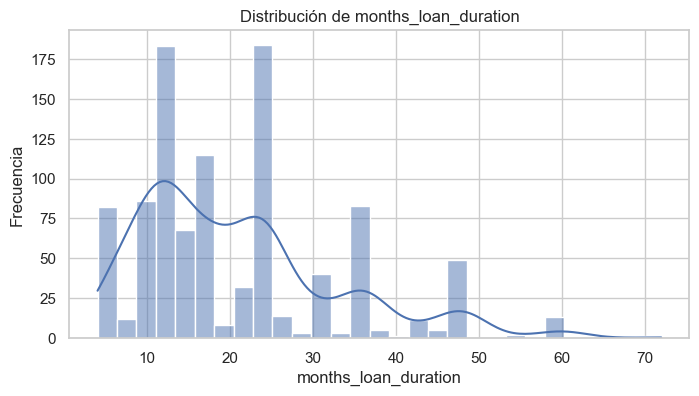

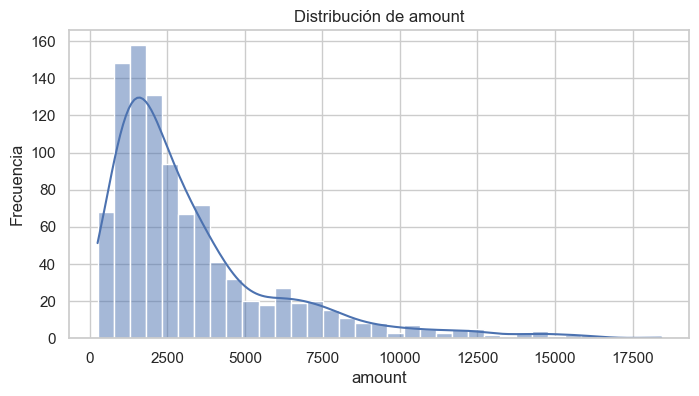

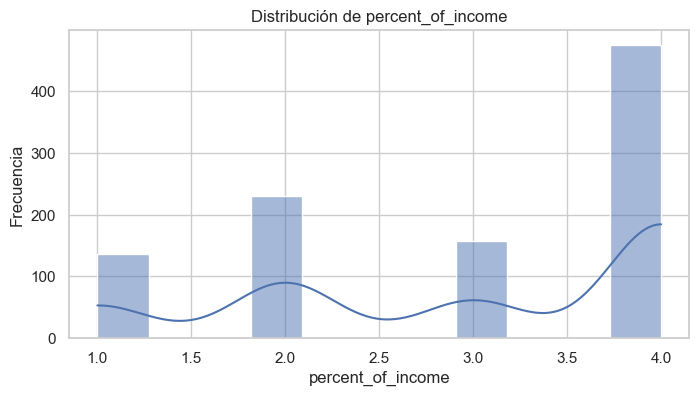

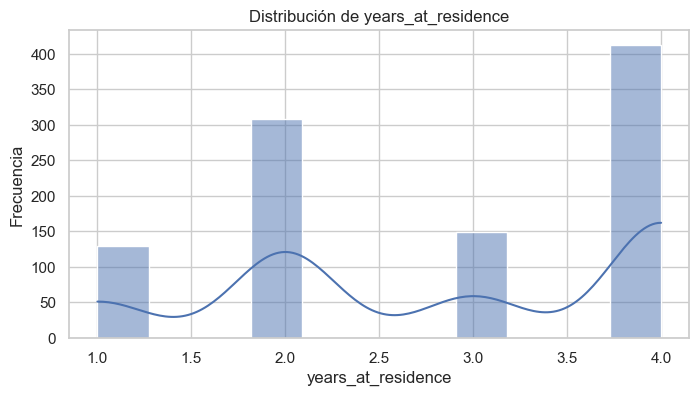

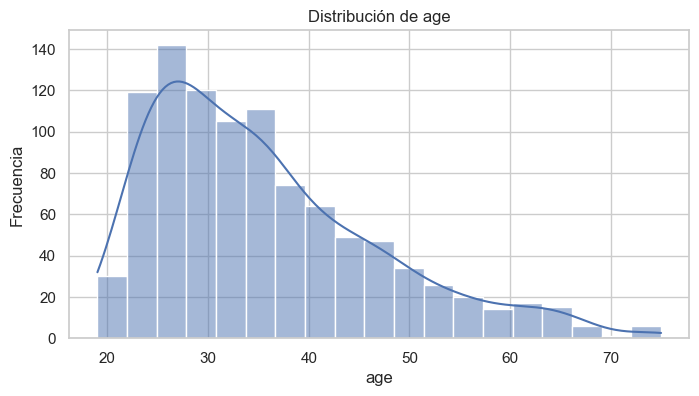

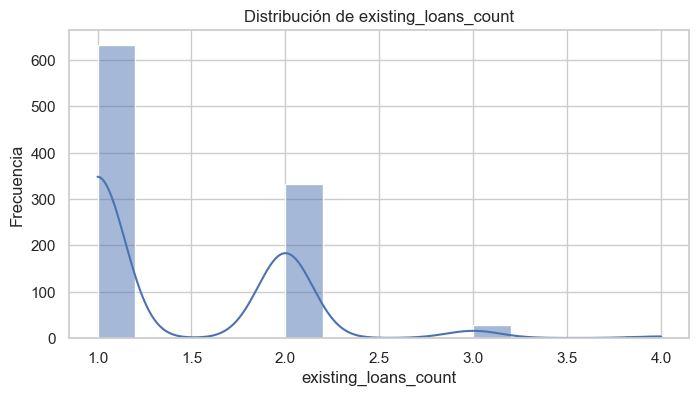

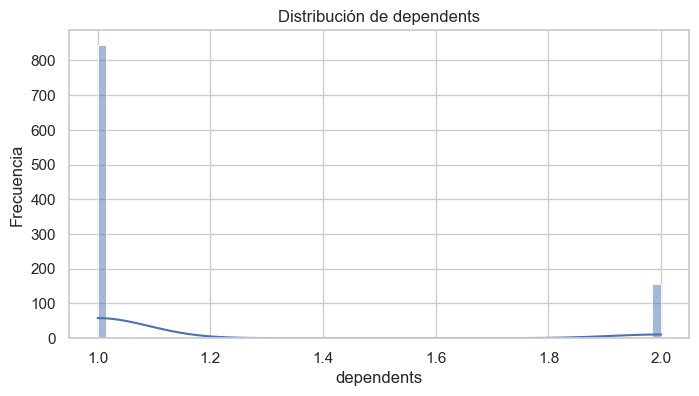

In [17]:
for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

Los histogramas permiten observar la forma de distribución de las variables numéricas. 
En este dataset, variables como `amount` y `months_loan_duration` presentan una distribución sesgada hacia valores bajos, con algunos casos de montos o duraciones más altas. 
Esto puede indicar la presencia de clientes con préstamos más grandes o de mayor duración.

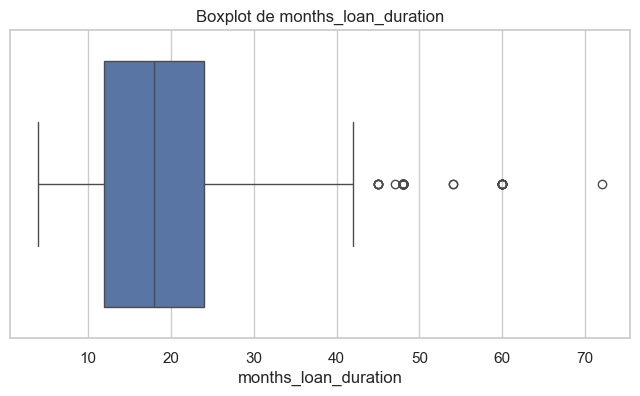

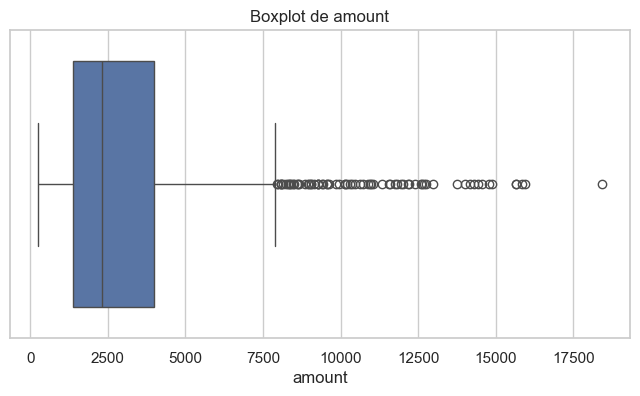

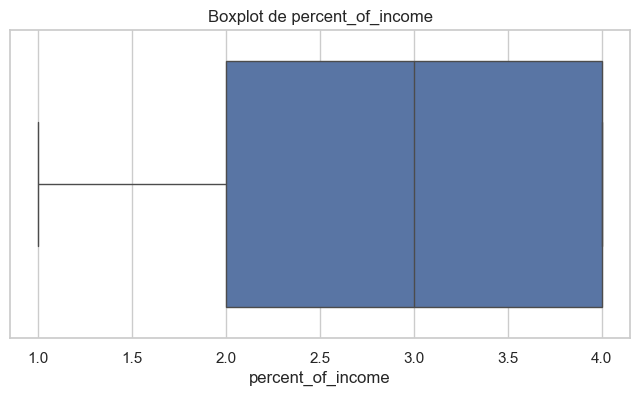

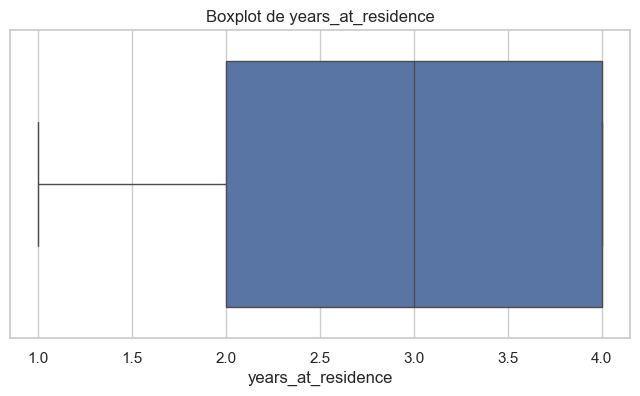

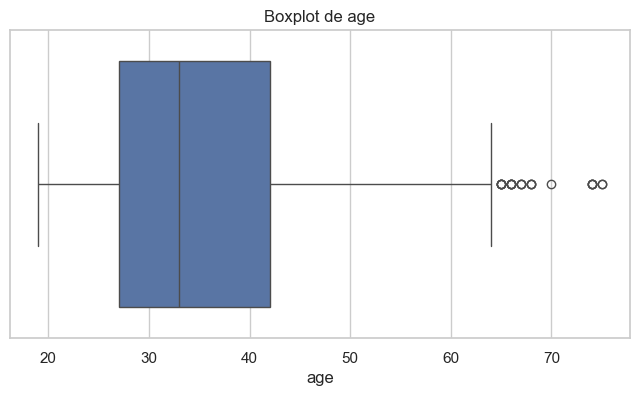

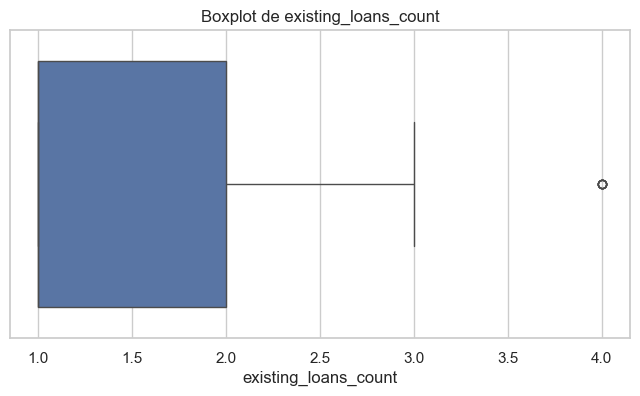

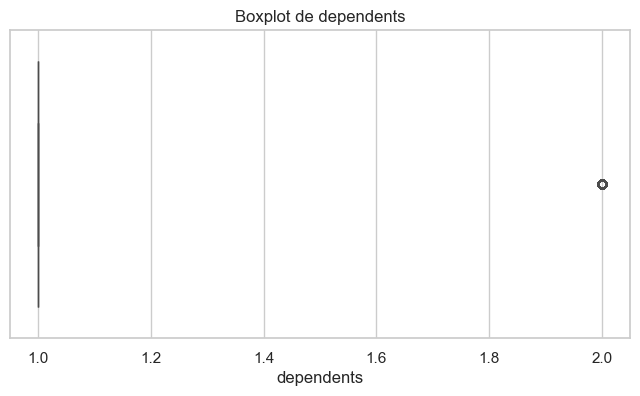

In [18]:
# Boxplots para revisar posibles outliers
for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

Los boxplots permiten identificar visualmente posibles valores atípicos. 
Se observan posibles outliers principalmente en variables como `amount`, `months_loan_duration` y `age`. 
Estos valores no necesariamente deben eliminarse, ya que pueden representar casos reales dentro del contexto financiero.

### **Identificando Outliers**

La revisión de valores atípicos (outliers) es importante porque pueden distorsionar el análisis estadístico y afectar el rendimiento de algunos modelos de machine learning. Algoritmos como la regresión lineal, K-Means o KNN son especialmente sensibles a estos valores extremos, mientras que los modelos basados en árboles suelen ser más robustos. Por ello, es recomendable identificarlos y evaluar si corresponden a errores o a comportamientos reales de los datos.

In [19]:
# Detección de outliers usando el método del rango intercuartílico
resumen_outliers = []

for col in columnas_numericas:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    
    resumen_outliers.append({
        "Variable": col,
        "Límite inferior": limite_inferior,
        "Límite superior": limite_superior,
        "Cantidad de outliers": outliers.shape[0],
        "Porcentaje de outliers": round((outliers.shape[0] / df.shape[0]) * 100, 2)
    })

tabla_outliers = pd.DataFrame(resumen_outliers)

tabla_outliers

,Variable,Límite inferior,Límite superior,Cantidad de outliers,Porcentaje de outliers
0,months_loan_duration,-6.000,42.000,70,7.0
1,amount,-2544.625,7882.375,72,7.2
2,percent_of_income,-1.000,7.000,0,0.0
3,years_at_residence,-1.000,7.000,0,0.0
4,age,4.500,64.500,23,2.3
5,existing_loans_count,-0.500,3.500,6,0.6
6,dependents,1.000,1.000,155,15.5


Se aplica el método IQR para detectar posibles outliers en las variables numéricas.

El IQR corresponde a la diferencia entre el tercer cuartil y el primer cuartil. A partir de este valor se calculan límites inferiores y superiores.

Los valores que quedan fuera de esos límites pueden considerarse posibles outliers.

Se identificaron posibles outliers en algunas variables numéricas. 
Las variables `amount` y `months_loan_duration` presentan valores altos que podrían representar créditos de mayor monto o duración. 
La variable `age` también presenta algunos valores atípicos, aunque estos pueden ser válidos en un contexto real.

En el caso de `dependents`, el método IQR puede marcar valores como outliers porque la variable solo toma pocos valores posibles. Por lo tanto, no se recomienda interpretar esos casos como errores automáticamente.

#### **Gráficos de barras para variables categóricas**

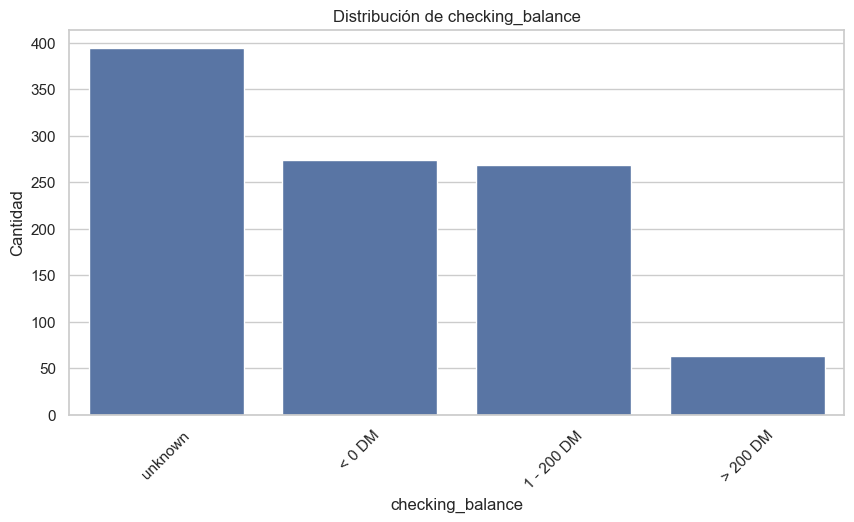

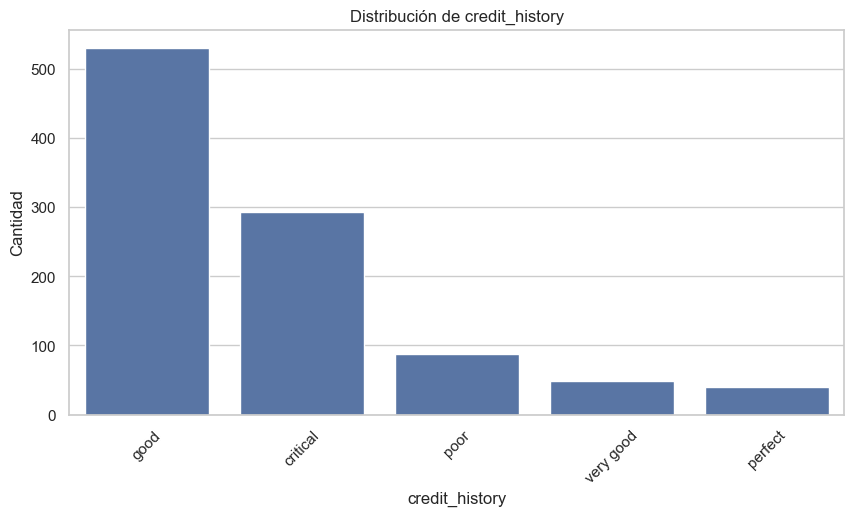

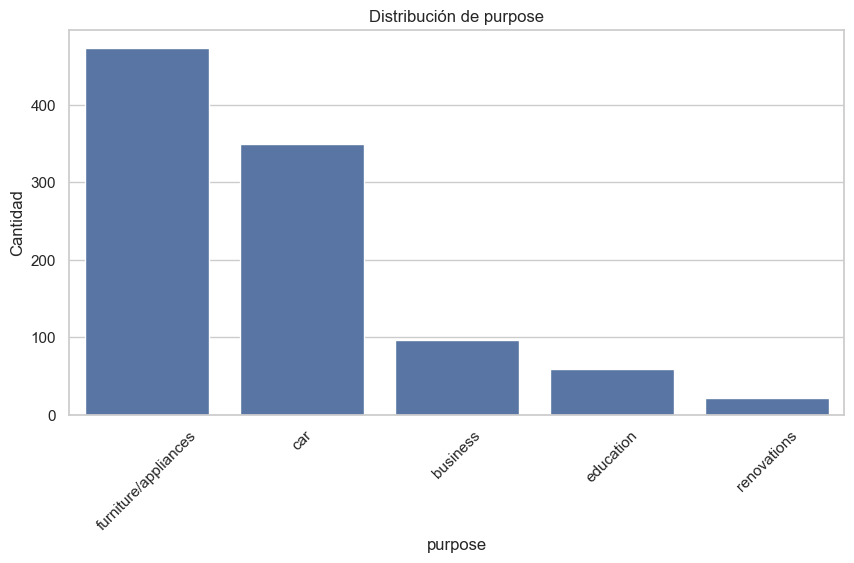

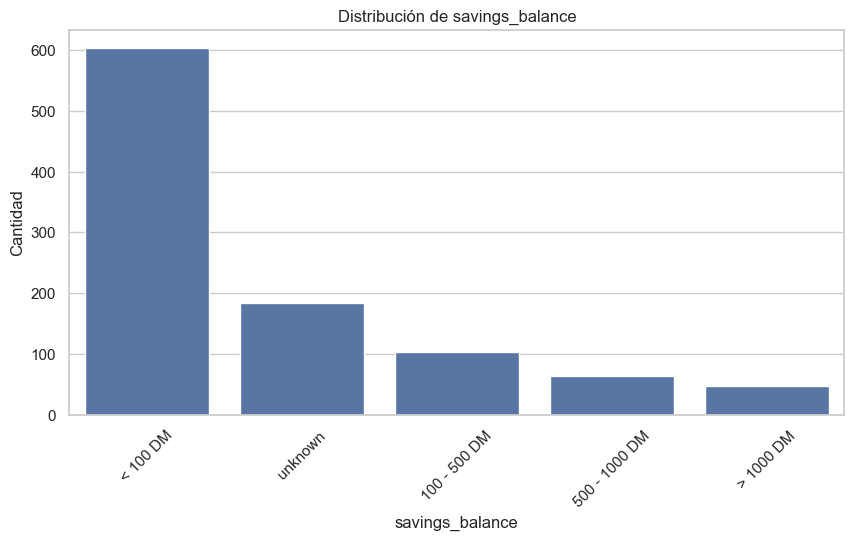

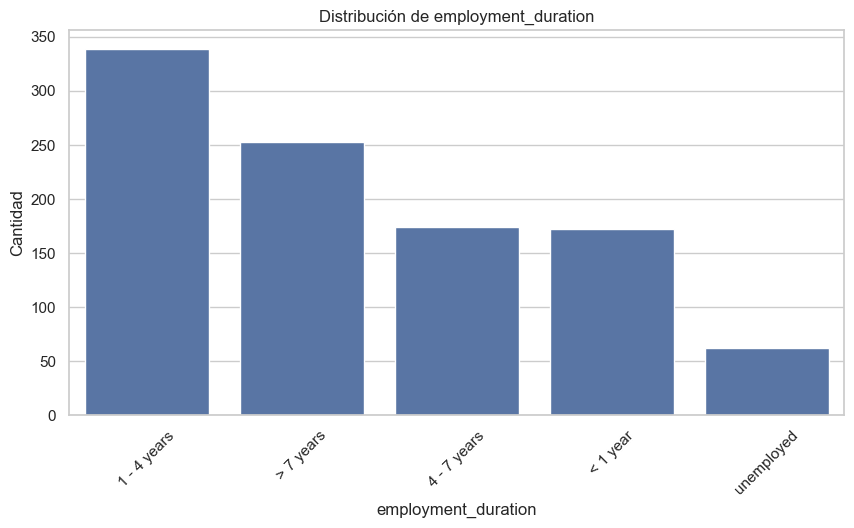

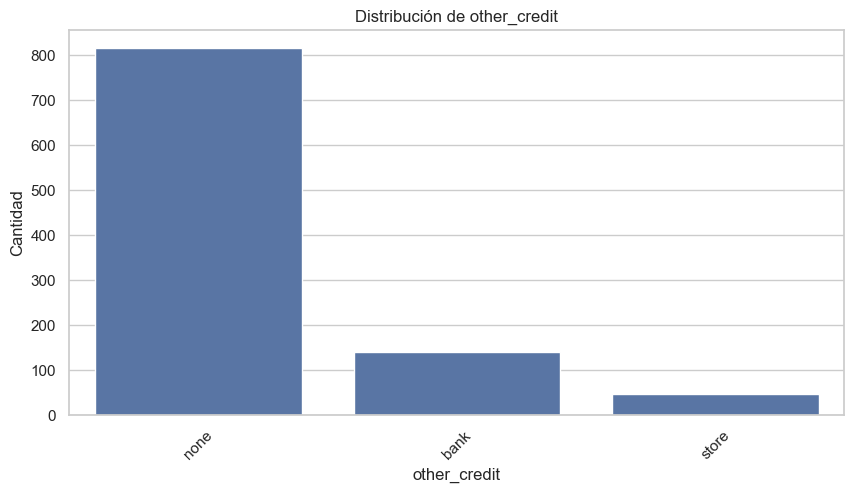

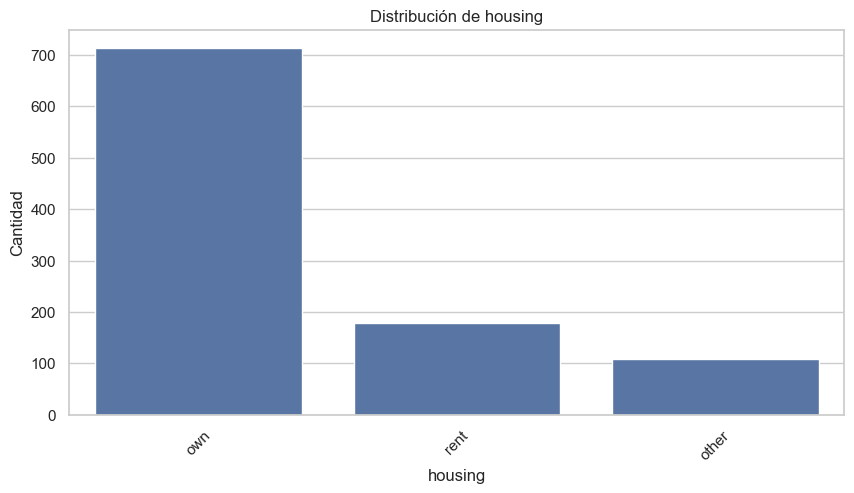

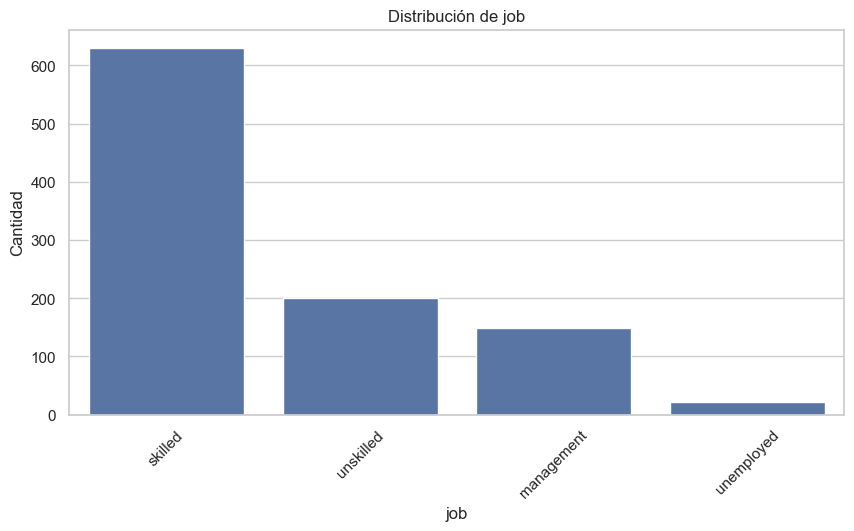

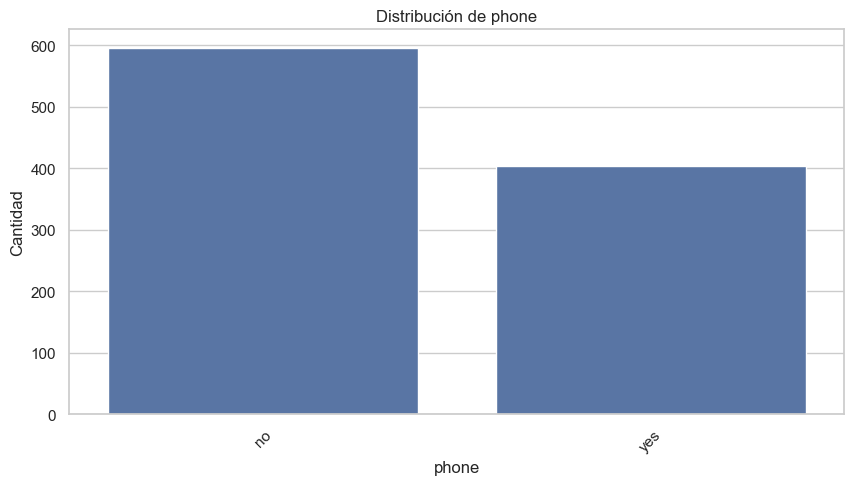

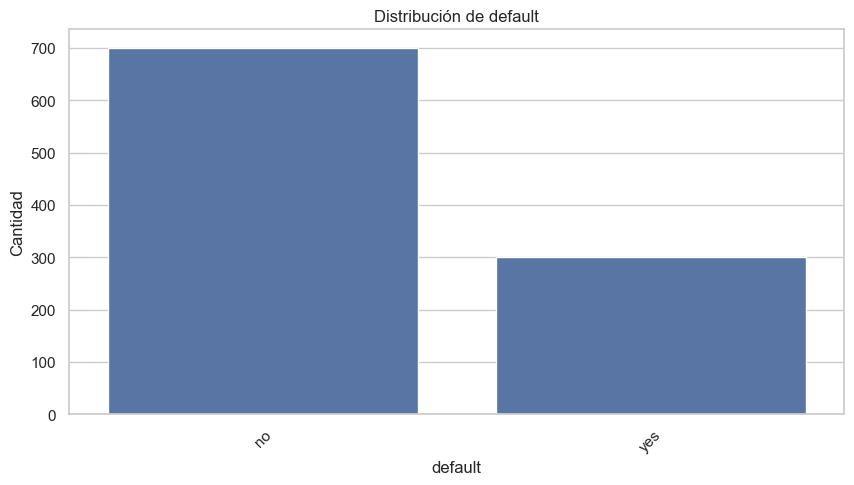

In [20]:


for col in columnas_categoricas:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Cantidad")
    plt.xticks(rotation=45)
    plt.show()

Se crean gráficos de barras para analizar la distribución de las principales variables categóricas.

Estos gráficos permiten observar qué categorías aparecen con mayor frecuencia dentro del dataset.
 
Se observa que algunas categorías concentran una gran parte de los registros, como clientes con vivienda propia, trabajadores calificados y personas sin otros créditos externos.

### **Visualizaciones del Análisis Exploratorio**

#### **Distribución de la variable objetivo**

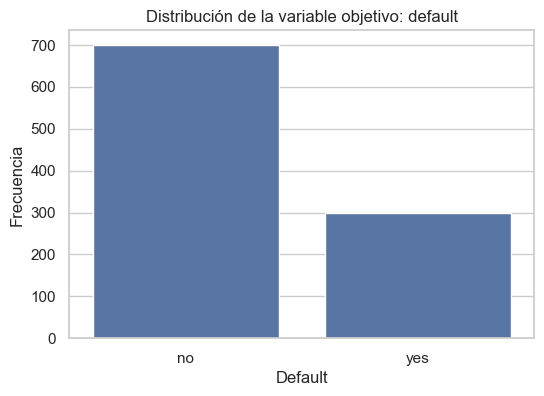

In [22]:
# Distribución de la variable objetivo
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="default",
    order=df["default"].value_counts().index
)

plt.title("Distribución de la variable objetivo: default")
plt.xlabel("Default")
plt.ylabel("Frecuencia")
plt.show()

La variable objetivo `default` indica si el cliente cayó o no en incumplimiento de pago. 
El dataset presenta 700 casos de clientes que no cayeron en default y 300 casos que sí cayeron en default. 
Esto equivale aproximadamente a un 70% para la clase `no` y un 30% para la clase `yes`.

Existe cierto desbalance entre clases, aunque no es extremo. 
Este punto debe considerarse si más adelante se entrena un modelo de clasificación.

#### **Mapa de calor de correlaciones**

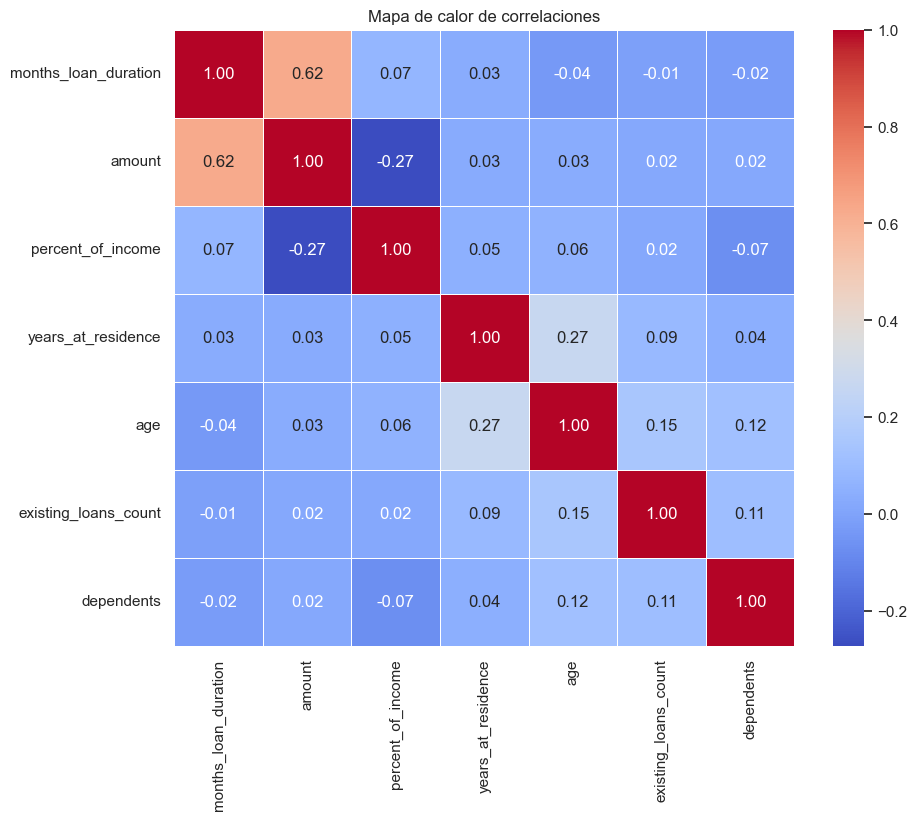

In [23]:
# Mapa de calor de correlaciones entre variables numéricas
plt.figure(figsize=(10, 8))

correlacion = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Mapa de calor de correlaciones")
plt.show()

El mapa de calor permite revisar la relación entre variables numéricas. 
La correlación más relevante se observa entre `amount` y `months_loan_duration`, lo cual tiene sentido porque los créditos de mayor monto suelen estar asociados a plazos más largos. 
También se observa una relación moderada entre `age` y `years_at_residence`.
La correlación entre `amount` y `months_loan_duration` es cercana a 0.62, lo que indica una relación positiva moderada-alta.

### **Análisis específico del dataset**

#### **Tasa de Default según Balance de Cuenta**

In [24]:
# Calculamos la tasa de default según checking_balance
default_checking = df.groupby("checking_balance")["default"].apply(
    lambda x: (x == "yes").mean() * 100
).sort_values(ascending=False)

default_checking

checking_balance
< 0 DM        49.270073
1 - 200 DM    39.033457
> 200 DM      22.222222
unknown       11.675127
Name: default, dtype: float64

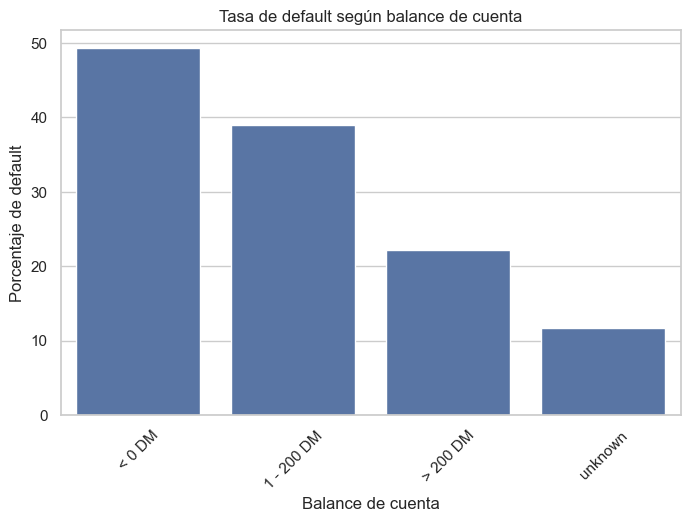

In [25]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=default_checking.index,
    y=default_checking.values
)

plt.title("Tasa de default según balance de cuenta")
plt.xlabel("Balance de cuenta")
plt.ylabel("Porcentaje de default")
plt.xticks(rotation=45)
plt.show()

Se observa que los clientes con balance de cuenta menor a 0 DM presentan una tasa de default más alta. 
Esto sugiere que el estado de la cuenta corriente puede ser una variable importante para predecir el riesgo crediticio.

#### **Tasa de Default según Historial Crediticio**

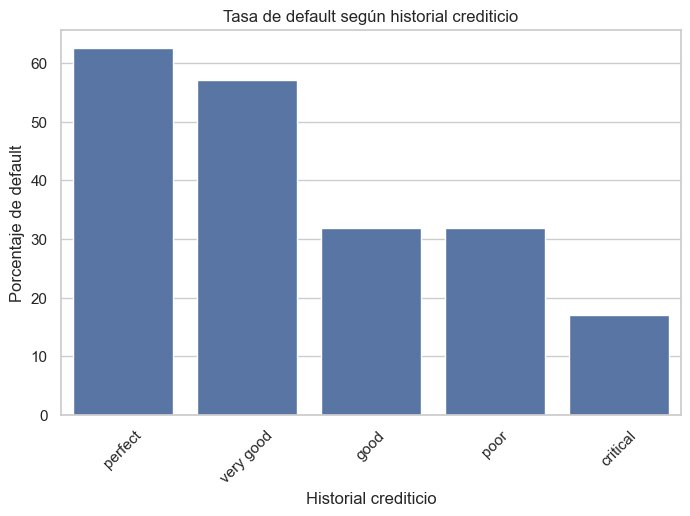

In [26]:
# Calculamos la tasa de default según historial crediticio
default_historial = df.groupby("credit_history")["default"].apply(
    lambda x: (x == "yes").mean() * 100
).sort_values(ascending=False)

default_historial

plt.figure(figsize=(8, 5))

sns.barplot(
    x=default_historial.index,
    y=default_historial.values
)

plt.title("Tasa de default según historial crediticio")
plt.xlabel("Historial crediticio")
plt.ylabel("Porcentaje de default")
plt.xticks(rotation=45)
plt.show()

El historial crediticio muestra diferencias importantes en la tasa de default. 
Algunas categorías presentan mayor proporción de incumplimiento, por lo que esta variable puede ser relevante para un futuro modelo de clasificación.

#### **Tasa de Default según Ahorros**

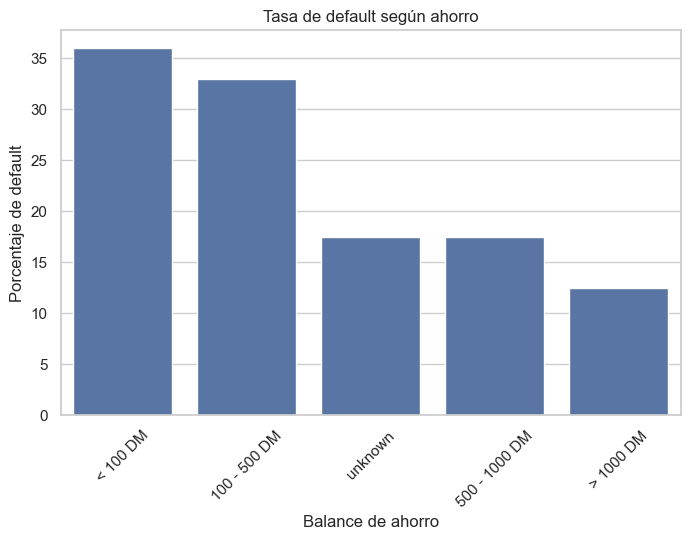

In [27]:
# Calculamos la tasa de default según savings_balance
default_savings = df.groupby("savings_balance")["default"].apply(
    lambda x: (x == "yes").mean() * 100
).sort_values(ascending=False)

default_savings
plt.figure(figsize=(8, 5))

sns.barplot(
    x=default_savings.index,
    y=default_savings.values
)

plt.title("Tasa de default según ahorro")
plt.xlabel("Balance de ahorro")
plt.ylabel("Porcentaje de default")
plt.xticks(rotation=45)
plt.show()

Los clientes con menor nivel de ahorro presentan una mayor tasa de default. 
Esto tiene sentido desde el punto de vista financiero, ya que una menor capacidad de ahorro puede asociarse con mayor riesgo de incumplimiento.

#### **Tasa de Default según Duración del Empleo**

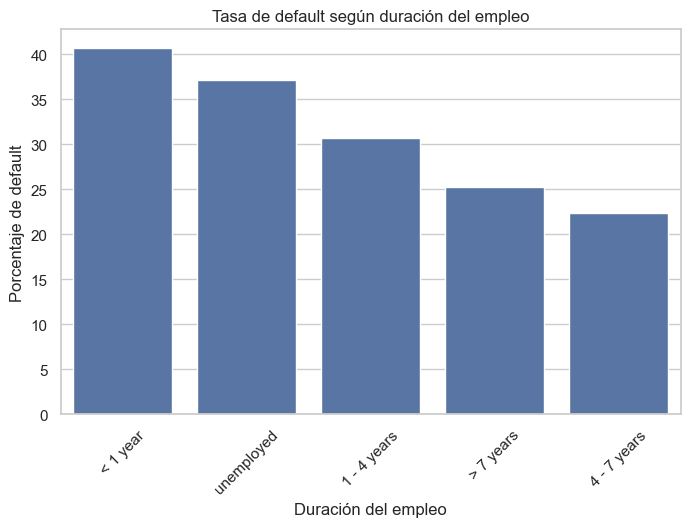

In [28]:
# Calculamos la tasa de default según duración del empleo
default_empleo = df.groupby("employment_duration")["default"].apply(
    lambda x: (x == "yes").mean() * 100
).sort_values(ascending=False)

default_empleo
plt.figure(figsize=(8, 5))

sns.barplot(
    x=default_empleo.index,
    y=default_empleo.values
)

plt.title("Tasa de default según duración del empleo")
plt.xlabel("Duración del empleo")
plt.ylabel("Porcentaje de default")
plt.xticks(rotation=45)
plt.show()

La duración del empleo también parece estar relacionada con el riesgo de default. 
Los clientes con menos de un año de empleo o desempleados presentan tasas más altas de incumplimiento. 
Esto puede indicar que la estabilidad laboral es un factor relevante en la evaluación del riesgo crediticio.

#### **Tabla Resumen por Default**

In [29]:
# Promedios de variables numéricas según default
df.groupby("default")[columnas_numericas].mean().round(2)

,months_loan_duration,amount,percent_of_income,years_at_residence,age,existing_loans_count,dependents
default,,,,,,,
no,19.21,2985.46,2.92,2.84,36.22,1.42,1.16
yes,24.86,3938.13,3.10,2.85,33.96,1.37,1.15


Al comparar los promedios según la variable `default`, se pueden observar diferencias entre los clientes que incumplieron y los que no. 
Este análisis permite identificar variables que podrían tener relación con el riesgo crediticio, como monto del préstamo, duración del crédito, edad o cantidad de préstamos existentes.

# **Resumen de Hallazgos**

El dataset de riesgo crediticio contiene 1000 registros y 17 variables. Presenta una estructura ordenada, sin valores nulos y sin registros duplicados, lo cual facilita el análisis inicial.

La variable objetivo es `default`, que indica si un cliente cayó o no en incumplimiento de pago. La distribución de esta variable muestra que aproximadamente el 70% de los clientes no cayó en default, mientras que el 30% sí lo hizo. Esto representa un leve desbalance de clases, pero no extremo.

Durante la revisión de variables categóricas se identificó una posible incongruencia en la variable `purpose`, donde aparece la categoría `car0`. Esta categoría fue corregida a `car`, ya que probablemente corresponde a un error de escritura.

En las variables numéricas se detectaron posibles outliers en `amount`, `months_loan_duration` y `age`. Estos valores no necesariamente deben eliminarse, ya que pueden representar casos reales dentro del contexto financiero. Por ejemplo, algunos clientes pueden solicitar créditos de mayor monto o con plazos más largos.

El análisis de correlaciones muestra una relación positiva importante entre `amount` y `months_loan_duration`, lo que indica que los préstamos de mayor monto suelen tener una mayor duración.

Además, el análisis específico muestra que algunas variables categóricas parecen estar relacionadas con la tasa de default. Por ejemplo, los clientes con balance de cuenta menor a 0 DM presentan una mayor proporción de incumplimiento. También se observa que los clientes con menor nivel de ahorro o menor estabilidad laboral tienden a presentar mayor riesgo.

En general, el dataset es adecuado para desarrollar un problema de clasificación binaria orientado a predecir si un cliente caerá o no en default.
# **Diagnóstico del Dataset**

El dataset presenta una buena calidad inicial, ya que no contiene valores nulos ni duplicados. 
Sin embargo, tiene algunos desafíos importantes que deben ser considerados antes de construir un modelo predictivo.

Uno de los principales desafíos es la presencia de variables categóricas, las cuales deberán ser transformadas mediante técnicas de codificación antes de entrenar un modelo de machine learning. 
También existe una leve desproporción en la variable objetivo, ya que la clase `no` representa el 70% de los casos y la clase `yes` representa el 30%.

Otro desafío es la presencia de posibles outliers en variables como `amount`, `months_loan_duration` y `age`. Estos valores deben analizarse con cuidado, ya que pueden ser casos válidos y relevantes para el análisis del riesgo crediticio.

A pesar de estos desafíos, el dataset es adecuado para trabajar una problemática de clasificación, ya que cuenta con una variable objetivo clara y con variables explicativas relacionadas con el comportamiento financiero del cliente.
# **Problemática Seleccionada**

La problemática seleccionada para este dataset es un problema de **clasificación binaria**.

El objetivo será predecir si un cliente caerá o no en default, utilizando sus características financieras y personales. 
La variable objetivo será `default`, la cual tiene dos categorías: `yes` y `no`.

Este problema es relevante porque permite apoyar la toma de decisiones en instituciones financieras. 
Un modelo predictivo podría ayudar a identificar clientes con mayor riesgo de incumplimiento y mejorar los procesos de evaluación crediticia.

Además, es un problema desafiante porque combina variables numéricas y categóricas, presenta posibles outliers y tiene cierto desbalance entre las clases de la variable objetivo.

# **Justificación de la Elección**

Se elige este dataset porque presenta una problemática clara, realista y útil dentro del área financiera. 
El riesgo crediticio es un tema importante para bancos, cooperativas, casas comerciales y otras instituciones que entregan préstamos.

A diferencia de otros datasets más simples, este conjunto de datos permite trabajar varias etapas importantes de un proyecto de ciencia de datos, como limpieza, análisis exploratorio, tratamiento de variables categóricas, detección de outliers, análisis de desbalance de clases y futura construcción de modelos de clasificación.

La variable objetivo `default` está claramente definida, lo que facilita plantear un modelo supervisado. 
Además, las variables disponibles tienen sentido para explicar el riesgo de incumplimiento, como historial crediticio, monto del préstamo, duración del crédito, nivel de ahorro, empleo, edad y situación habitacional.

Por estas razones, este dataset es una buena opción para desarrollar el Proyecto 2.

El dataset de riesgo crediticio es una opción sólida para el Proyecto 2, ya que permite abordar un problema de clasificación binaria con una variable objetivo clara: `default`. 
El dataset está limpio en términos de nulos y duplicados, pero presenta desafíos interesantes como variables categóricas, posibles outliers, una categoría incongruente en `purpose` y cierto desbalance de clases.

Por lo tanto, este dataset tiene un nivel intermedio y es adecuado para demostrar un análisis exploratorio completo y una futura etapa de modelamiento predictivo.